#  Tech Assessment: Weather Trend Forecasting

Candidate: Sirpreet Kaur Dhillon <br>
Role: AI Engineer Intern - Technical Assessment<br>
Submission Date: March 4, 2026

## Objective
Analyze the "Global Weather Repository.csv" dataset to forecast future weather trends and showcase data science skills through both basic and advanced techniques.

## PM Accelerator Mission
"By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. This is the PM Accelerator motto, as we grant aspiring and experienced PMs what they need most – Access. We introduce you to industry leaders, surround you with the right PM ecosystem, and discover the new world of AI product management skills."


### All Imports and Data injestion

Run the following command on your local computer to install all prerequisites 

pip install -r requirements.txt

In [1]:
# All Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
from sklearn.preprocessing import StandardScaler

In [3]:
# Set visualization style
sns.set_theme(style="whitegrid")

In [ ]:
# Load the dataset
data = pd.read_csv('GlobalWeatherRepository.csv')

### Correlation Heatmap 
Used the following heatmap to understand the correlation between any two weather features. It also helped me drop almost identical features which provided information twice. 

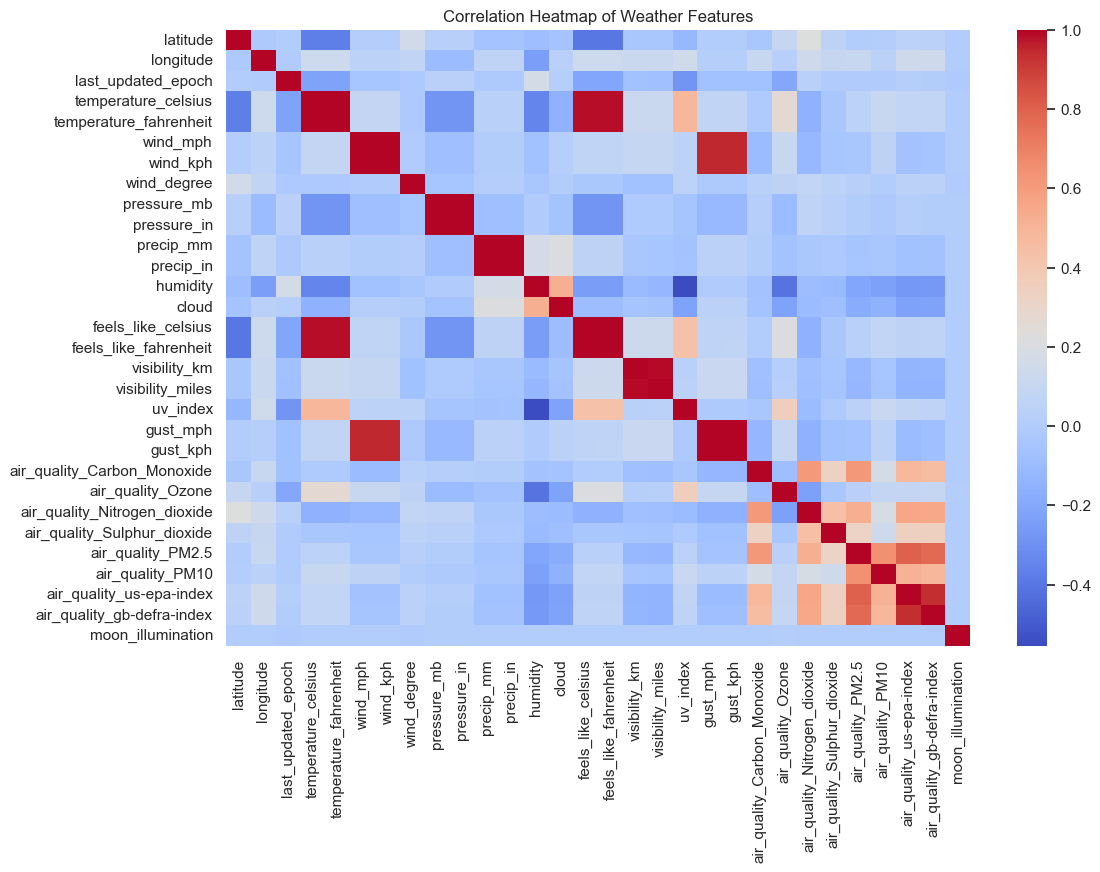

In [4]:
# Select only numerical columns for correlation
numerical_df = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Weather Features')
plt.show()

In [6]:
# Dropping redundant features / columns with high correlation
redundant_cols = ['temperature_fahrenheit', 'wind_mph', 'pressure_in', 'precip_in', 'feels_like_fahrenheit']
data_clean = data.drop(columns=redundant_cols)

In [7]:
# Time Series Preparation 
data_clean['last_updated'] = pd.to_datetime(data_clean['last_updated'])
data_clean.set_index('last_updated', inplace=True)
data_clean.sort_index(inplace=True)

### Data Cleaning & Preprocessing
- Handling missing values using forward fill 
- Normalizing data using StandardScaler

In [11]:
# Handle missing values (Forward fill for time series)
data_clean = data_clean.ffill()

# Normalize numerical data for ML models
scaler = StandardScaler()
num_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'air_quality_PM2.5']
data_clean[num_cols] = scaler.fit_transform(data_clean[num_cols])

### Exploratory Data Analysis (EDA)
- Perform basic EDA to uncover the trends, correlations, and patterns.
- Generate visualizations for temperature and precipitation.

The goal here is to visualize the core trends of the dataset: Temperature and Precipitation.

In [12]:
# Set the style for professional plots
plt.style.use('ggplot')

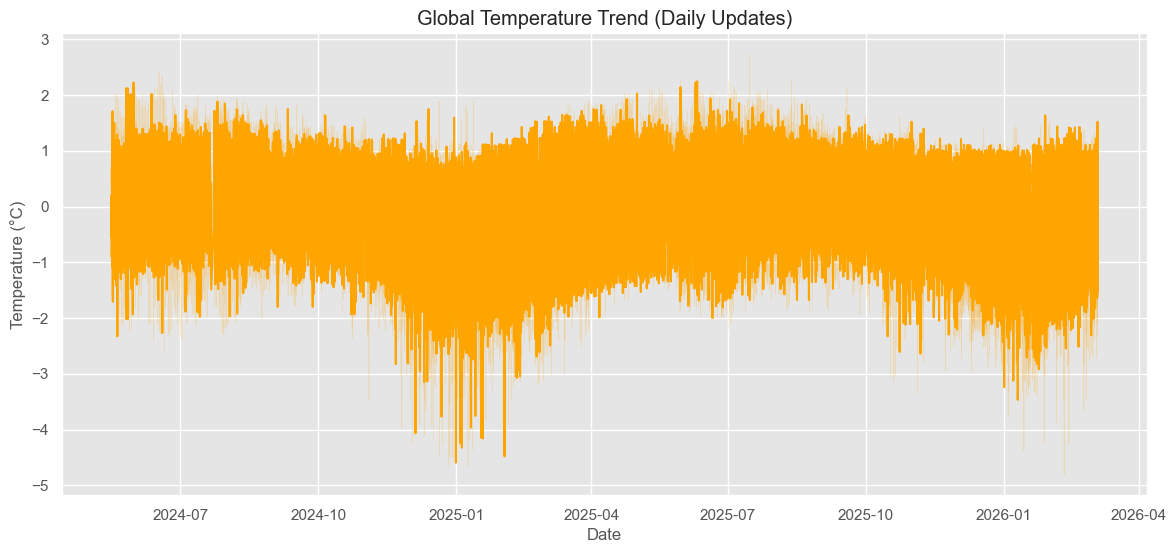

In [15]:
# Temperature Trend over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=data_clean, x='last_updated', y='temperature_celsius', color='orange')
plt.title('Global Temperature Trend (Daily Updates)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

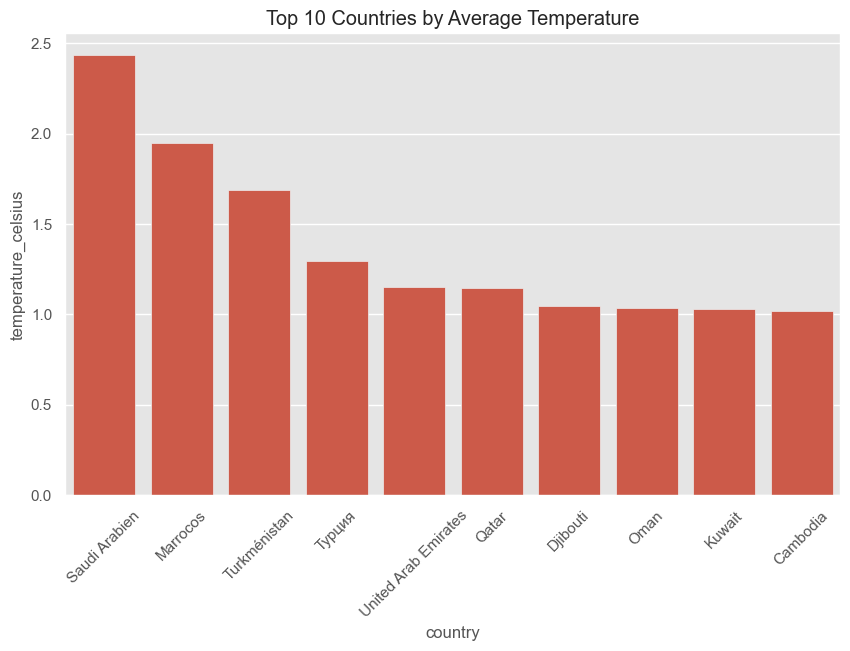

In [14]:
# Group by country to see average conditions
country_stats = data_clean.groupby('country')[['temperature_celsius', 'air_quality_PM2.5']].mean().sort_values(by='temperature_celsius', ascending=False)

# Visualize Top 10 hottest countries in the dataset
plt.figure(figsize=(10,6))
sns.barplot(x=country_stats.head(10).index, y=country_stats.head(10)['temperature_celsius'])
plt.title("Top 10 Countries by Average Temperature")
plt.xticks(rotation=45)
plt.show()

## Advanced EDA